# 1. Import and Hardware Setup

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset
import os
import random
import matplotlib.pyplot as plt
import numpy as np
!pip install tqdm -q
from tqdm.auto import tqdm
# Set device to GPU, MPS, or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [21]:
DATA_PATH = './data'

# 2. Hyperparameter

In [22]:
BATCH_SIZE = 256
IMG_SIZE = 128
IN_CHANNELS = 3

LR = 2e-4
EPOCHS = 50
SEED = 42
NUM_CLASSES = 50

ENCODER_CHANNELS = [32, 64, 128, 256]

# VQ-VAE specific hyperparameters
# Number of embedding vectors in the codebook (vocabulary size).
# A larger codebook increases expressiveness but may be harder to train.
NUM_EMBEDDINGS = 512

# Dimensionality of each embedding vector in the codebook.
# Must match the encoder output channels.
EMBEDDING_DIM = 256

# Weight for the commitment loss term.
# Encourages the encoder output to stay close to the chosen codebook entry.
# beta in the original VQ-VAE paper (van den Oord et al., 2017).
COMMITMENT_COST = 0.25

# 3. Data Preparation

In [23]:
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    """Seed function for DataLoader workers to ensure reproducibility."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [24]:
train_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]
)

# Apply seed
set_seed(SEED)
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

filtered_indices = [i for i, label in enumerate(dummy_data._labels) if label < NUM_CLASSES]

train_size = int(0.8 * len(filtered_indices))
val_size = len(filtered_indices) - train_size
split_generator = torch.Generator().manual_seed(SEED)

filtered_dummy_data = Subset(dummy_data, filtered_indices)
train_tmp_subset, val_tmp_subset = random_split(
    filtered_dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = [filtered_indices[i] for i in train_tmp_subset.indices]
val_indices = [filtered_indices[i] for i in val_tmp_subset.indices]

train_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=train_transform,
)

val_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=val_transform,
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)


dummy_test_dataset = datasets.Food101(root=DATA_PATH, split="test", download=True)
test_filterd_indices = [
    i for i, label in enumerate(dummy_test_dataset._labels) if label < NUM_CLASSES
]

test_dataset_full = datasets.Food101(
    root=DATA_PATH,
    split="test",
    download=False,
    transform=val_transform,
)
test_dataset = Subset(test_dataset_full, test_filterd_indices)

In [25]:
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

# 4. Model Architecture

## VQ-VAE Key Differences vs. Standard VAE

1. **Discrete latent space**: Instead of sampling from a continuous distribution N(mu, sigma^2), VQ-VAE maps the encoder output to the *nearest* vector in a learned discrete codebook. The latent space is therefore discrete.
2. **Vector Quantization**: The codebook contains `NUM_EMBEDDINGS` embedding vectors of size `EMBEDDING_DIM`. Each spatial position of the encoder output is independently quantized to the closest codebook entry.
3. **Straight-Through Estimator**: Because the argmin operation (nearest neighbor lookup) is not differentiable, gradients are passed straight through the quantization step from the decoder input to the encoder output.
4. **Loss = Reconstruction + Codebook Loss + Commitment Loss**:
   - Reconstruction Loss (MSE): Standard pixel-level reconstruction.
   - Codebook Loss: `||sg[z_e] - e||^2` — moves codebook entries towards encoder outputs (`sg` = stop gradient).
   - Commitment Loss: `beta * ||z_e - sg[e]||^2` — encourages the encoder to commit to a codebook entry.
5. **No KL divergence**: Unlike VAE/CVAE, VQ-VAE does not use a KL term. The regularization comes from the discrete codebook structure itself.

In [26]:
class ConvBA(nn.Sequential):
    """Convolutional block with BatchNorm and LeakyReLU activation."""
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,  # to reduce the resolution
        padding=1,
    ):
        super().__init__(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class ConvTransBA(nn.Sequential):
    """Transposed convolutional block with BatchNorm and LeakyReLU activation."""
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,
        padding=1,
        output_padding=1,
    ):
        super().__init__(
            nn.ConvTranspose2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                output_padding=output_padding,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class VectorQuantizer(nn.Module):
    """
    Vector Quantization layer (VQ) as described in:
    'Neural Discrete Representation Learning' (van den Oord et al., 2017).

    The encoder output z_e is mapped to the nearest codebook entry e_k.
    Gradients flow from the decoder back to the encoder via the
    straight-through estimator (STE): the quantized vector is replaced
    by z_e in the backward pass.

    Args:
        num_embeddings: Number of discrete vectors in the codebook (K).
        embedding_dim:  Dimension of each codebook vector (D).
        commitment_cost: Weight for the commitment loss term (beta).
    """
    def __init__(self, num_embeddings: int, embedding_dim: int, commitment_cost: float):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost

        # Codebook: K x D matrix of learnable embedding vectors
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)

        # Initialize embeddings with a uniform distribution (common practice)
        nn.init.uniform_(
            self.embedding.weight,
            -1.0 / num_embeddings,
            1.0 / num_embeddings,
        )

    def forward(self, z_e):
        """
        Quantize the encoder output z_e.

        Args:
            z_e: Encoder output of shape (B, C, H, W), where C == embedding_dim.

        Returns:
            z_q:            Quantized tensor of shape (B, C, H, W) with STE applied.
            loss:           VQ loss = codebook loss + commitment loss.
            codebook_loss:  ||sg[z_e] - e||^2 (detached from encoder).
            commit_loss:    beta * ||z_e - sg[e]||^2 (detached from codebook).
            encoding_indices: Indices of chosen codebook entries (B, H*W).
            perplexity:     Effective codebook usage metric.
        """
        # (B, C, H, W) -> (B, H, W, C) -> (B*H*W, C)
        z_e_flat = z_e.permute(0, 2, 3, 1).contiguous()
        b, h, w, c = z_e_flat.shape
        z_e_flat = z_e_flat.view(-1, c)  # (N, C) where N = B*H*W

        # Compute squared L2 distances between encoder outputs and codebook entries:
        # ||z_e - e||^2 = ||z_e||^2 + ||e||^2 - 2 * z_e @ e^T
        distances = (
            z_e_flat.pow(2).sum(dim=1, keepdim=True)           # (N, 1)
            + self.embedding.weight.pow(2).sum(dim=1)           # (K,)
            - 2.0 * z_e_flat @ self.embedding.weight.t()        # (N, K)
        )  # Result shape: (N, K)

        # Select the nearest codebook entry for each spatial position
        encoding_indices = distances.argmin(dim=1)  # (N,)
        encodings = F.one_hot(encoding_indices, self.num_embeddings).float()  # (N, K)

        # Retrieve the quantized vectors from the codebook
        z_q_flat = encodings @ self.embedding.weight  # (N, C)

        # Reshape back to spatial format (B, H, W, C) -> (B, C, H, W)
        z_q = z_q_flat.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()

        # ---------- Losses ----------
        # Codebook loss: moves codebook entries towards encoder outputs.
        # sg[z_e] means z_e is detached (no gradient to encoder).
        codebook_loss = F.mse_loss(z_q, z_e.detach())

        # Commitment loss: encourages encoder to commit to a codebook entry.
        # sg[z_q] means z_q is detached (no gradient to codebook).
        commit_loss = F.mse_loss(z_e, z_q.detach())

        loss = codebook_loss + self.commitment_cost * commit_loss

        # Straight-Through Estimator (STE):
        # Replace z_q with z_e in the backward pass so gradients flow to encoder.
        # In the forward pass, z_q is used (discrete lookup).
        z_q = z_e + (z_q - z_e).detach()

        # Perplexity: measures how many codebook entries are effectively used.
        # High perplexity = diverse codebook usage (good).
        # Low perplexity = codebook collapse (bad).
        avg_probs = encodings.mean(dim=0)  # (K,)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        return z_q, loss, codebook_loss, commit_loss, encoding_indices.view(b, h * w), perplexity


class VectorQuantizedVAE(nn.Module):
    """
    Vector-Quantized Variational Autoencoder (VQ-VAE).

    Unlike a standard VAE, the VQ-VAE uses a discrete codebook instead of
    a continuous latent distribution. The encoder output is quantized to the
    nearest codebook vector via Vector Quantization (VQ).

    Architecture:
        Encoder: Convolutional layers that downsample the input image.
        VQ Layer: Discretizes the encoder output using the codebook.
        Decoder: Transposed convolutional layers that upsample back to image size.

    The encoder output channels must equal EMBEDDING_DIM.
    """
    def __init__(
        self,
        in_channels: int,
        img_size: int,
        encoder_channels: list,
        num_embeddings: int,
        embedding_dim: int,
        commitment_cost: float,
    ):
        super().__init__()

        num_layers = len(encoder_channels)

        # The spatial resolution of the feature map after the encoder.
        # Only (num_layers - 1) ConvBA layers use stride=2; the last
        # encoder layer is a stride=1 Conv2d (channel projection only).
        self.final_h = img_size // (2 ** (num_layers - 1))
        self.final_w = img_size // (2 ** (num_layers - 1))

        assert self.final_h >= 1 and self.final_w >= 1, "Too many downsamplings"
        assert encoder_channels[-1] == embedding_dim, (
            f"Last encoder channel ({encoder_channels[-1]}) must equal "
            f"embedding_dim ({embedding_dim})."
        )

        # -------------- Encoder --------------
        encoder_layers = []
        curr_channels = in_channels

        for out_channels in encoder_channels[:-1]:
            encoder_layers.append(ConvBA(curr_channels, out_channels))
            curr_channels = out_channels

        # Last encoder layer with stride=1 to preserve spatial resolution
        # after downsampling, then project to embedding_dim channels.
        encoder_layers.append(
            nn.Conv2d(curr_channels, embedding_dim, kernel_size=3, padding=1)
        )
        self.encoder = nn.Sequential(*encoder_layers)

        # -------------- Vector Quantization Layer --------------
        self.vq_layer = VectorQuantizer(num_embeddings, embedding_dim, commitment_cost)

        # -------------- Decoder --------------
        decoder_layers = []

        rev_channels = list(reversed(encoder_channels))
        # First decoder layer: project from embedding_dim back to first decoder channel
        decoder_layers.append(
            nn.Conv2d(embedding_dim, rev_channels[0], kernel_size=3, padding=1)
        )

        for i in range(len(rev_channels) - 1):
            curr_ch = rev_channels[i]
            out_ch = rev_channels[i + 1]
            decoder_layers.append(ConvTransBA(curr_ch, out_ch))

        # Final output layer: 1x1-style conv to map back to image channels.
        # No extra upsampling here — the (num_layers-1) ConvTransBA layers
        # already match the (num_layers-1) stride-2 ConvBA layers in the encoder.
        decoder_layers.extend(
            [
                nn.Conv2d(
                    in_channels=rev_channels[-1],
                    out_channels=in_channels,
                    kernel_size=3,
                    padding=1,
                ),
                nn.Sigmoid(),
            ]
        )

        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        """Encode input image to a continuous feature map z_e."""
        return self.encoder(x)

    def decode(self, z_q):
        """Decode a quantized feature map z_q to a reconstructed image."""
        return self.decoder(z_q)

    def forward(self, x):
        """
        Forward pass: encode -> vector quantize -> decode.

        Returns:
            reconstructed:    Reconstructed image.
            vq_loss:          Total VQ loss (codebook + commitment).
            codebook_loss:    Codebook update loss.
            commit_loss:      Commitment loss.
            encoding_indices: Chosen codebook indices per spatial position.
            perplexity:       Codebook usage metric.
        """
        z_e = self.encode(x)
        z_q, vq_loss, codebook_loss, commit_loss, encoding_indices, perplexity = (
            self.vq_layer(z_e)
        )
        reconstructed = self.decode(z_q)
        return reconstructed, vq_loss, codebook_loss, commit_loss, encoding_indices, perplexity

In [27]:
model = VectorQuantizedVAE(
    in_channels=IN_CHANNELS,
    img_size=IMG_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    num_embeddings=NUM_EMBEDDINGS,
    embedding_dim=EMBEDDING_DIM,
    commitment_cost=COMMITMENT_COST,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters()) / 1e6):.2f}M")
print(f"Encoder output spatial size: {model.final_h} x {model.final_w}")
print(f"Codebook size: {NUM_EMBEDDINGS} x {EMBEDDING_DIM}")

Total parameters: 1.50M
Encoder output spatial size: 16 x 16
Codebook size: 512 x 256


# 5. Loss Function

In [28]:
def vqvae_loss(reconstructed, original, vq_loss):
    """
    VQ-VAE loss = Reconstruction Loss + VQ Loss.

    Unlike VAE, there is no KL divergence term. The VQ loss handles
    the regularization of the discrete latent space.

    - Reconstruction Loss: MSE between original and reconstructed images.
    - VQ Loss: codebook_loss + commitment_cost * commit_loss.
      - codebook_loss:  ||sg[z_e] - e||^2  (trains the codebook).
      - commit_loss:    ||z_e - sg[e]||^2  (trains the encoder to commit).

    Args:
        reconstructed: Reconstructed images from the decoder.
        original:      Original input images.
        vq_loss:       Total VQ loss returned by the VectorQuantizer.

    Returns:
        total_loss: Sum of reconstruction loss and VQ loss.
        recon_loss: Reconstruction loss (MSE) for logging.
    """
    # Reconstruction loss (MSE, per-pixel average)
    # Using reduction='mean' for numerical stability under mixed precision
    # (float16). Large sums from reduction='sum' easily overflow float16.
    recon_loss = F.mse_loss(reconstructed, original, reduction='mean')

    total_loss = recon_loss + vq_loss
    return total_loss, recon_loss

# 6. Train

In [29]:
class EarlyStopping:
    """Early stopping to halt training when validation loss stops improving."""
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expected
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        """Save the model checkpoint."""
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)


In [30]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)
scaler = torch.amp.GradScaler(device=device)

In [31]:
def train_epoch(model, loader, optimizer, scaler):
    """Train the VQ-VAE for one epoch."""
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_vq = 0.0
    total_perplexity = 0.0
    loop = tqdm(loader, desc="Training", leave=False)
    
    for images, _ in loop:
        images = images.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        with torch.autocast(device_type=device.type):
            reconstructed, vq_loss, codebook_loss, commit_loss, _, perplexity = (
                model(images)
            )
            loss, recon_loss = vqvae_loss(reconstructed, images, vq_loss)
        
        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()
        
        # Unscale and clip the gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update the parameters
        scaler.step(optimizer)
        
        # Update the scaler
        scaler.update()
        
        batch_size = images.size(0)
        total_loss += loss.detach() * batch_size
        total_recon += recon_loss.detach() * batch_size
        total_vq += vq_loss.detach() * batch_size
        total_perplexity += perplexity.detach() * batch_size

    n = len(loader.dataset)
    return (
        total_loss.item() / n,
        total_recon.item() / n,
        total_vq.item() / n,
        total_perplexity.item() / n,
    )


def validate_epoch(model, loader):
    """Validate the VQ-VAE for one epoch."""
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_vq = 0.0
    total_perplexity = 0.0
    loop = tqdm(loader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for images, _ in loop:
            images = images.to(device)
            reconstructed, vq_loss, codebook_loss, commit_loss, _, perplexity = (
                model(images)
            )
            loss, recon_loss = vqvae_loss(reconstructed, images, vq_loss)
            batch_size = images.size(0)
            total_loss += loss.detach() * batch_size
            total_recon += recon_loss.detach() * batch_size
            total_vq += vq_loss.detach() * batch_size
            total_perplexity += perplexity.detach() * batch_size

    n = len(loader.dataset)
    return (
        total_loss.item() / n,
        total_recon.item() / n,
        total_vq.item() / n,
        total_perplexity.item() / n,
    )

In [32]:
early_stopping = EarlyStopping(patience=5, save_path="best_vqvae_checkpoint.pth")
train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []
train_vq_losses = []
val_vq_losses = []
train_perplexities = []
val_perplexities = []

for epoch in range(EPOCHS):
    train_loss, train_recon, train_vq, train_perp = train_epoch(
        model, train_loader, optimizer, scaler
    )
    val_loss, val_recon, val_vq, val_perp = validate_epoch(
        model, val_loader
    )
    
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_vq_losses.append(train_vq)
    val_vq_losses.append(val_vq)
    train_perplexities.append(train_perp)
    val_perplexities.append(val_perp)
    
    print(
        f"Epoch {epoch+1}/{EPOCHS}: "
        f"Train Loss: {train_loss:.6f} (Recon: {train_recon:.6f}, VQ: {train_vq:.4f}, Perplexity: {train_perp:.1f}) | "
        f"Val Loss: {val_loss:.6f} (Recon: {val_recon:.6f}, VQ: {val_vq:.4f}, Perplexity: {val_perp:.1f})"
    )
    
    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best model for evaluation
model.load_state_dict(torch.load("best_vqvae_checkpoint.pth"))

Training:   0%|          | 0/118 [00:00<?, ?it/s]

/tmp/ipykernel_25523/2869088700.py:106: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  - 2.0 * z_e_flat @ self.embedding.weight.t()        # (N, K)
/tmp/ipykernel_25523/2869088700.py:114: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable d

Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/50: Train Loss: 5.775601 (Recon: 0.040285, VQ: 5.7353, Perplexity: 14.7) | Val Loss: 3.034883 (Recon: 0.021373, VQ: 3.0135, Perplexity: 9.9)


Training:   0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 40/50: Train Loss: 0.050456 (Recon: 0.008554, VQ: 0.0419, Perplexity: 35.8) | Val Loss: 0.042073 (Recon: 0.007498, VQ: 0.0346, Perplexity: 34.4)
Early Stopping counter: 4 out of 5


Training:   0%|          | 0/118 [00:00<?, ?it/s]

Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 41/50: Train Loss: 0.050184 (Recon: 0.008506, VQ: 0.0417, Perplexity: 35.8) | Val Loss: 0.041901 (Recon: 0.007486, VQ: 0.0344, Perplexity: 34.4)
Early Stopping counter: 5 out of 5
Early stopping triggered


<All keys matched successfully>

# 7. Result Visualization

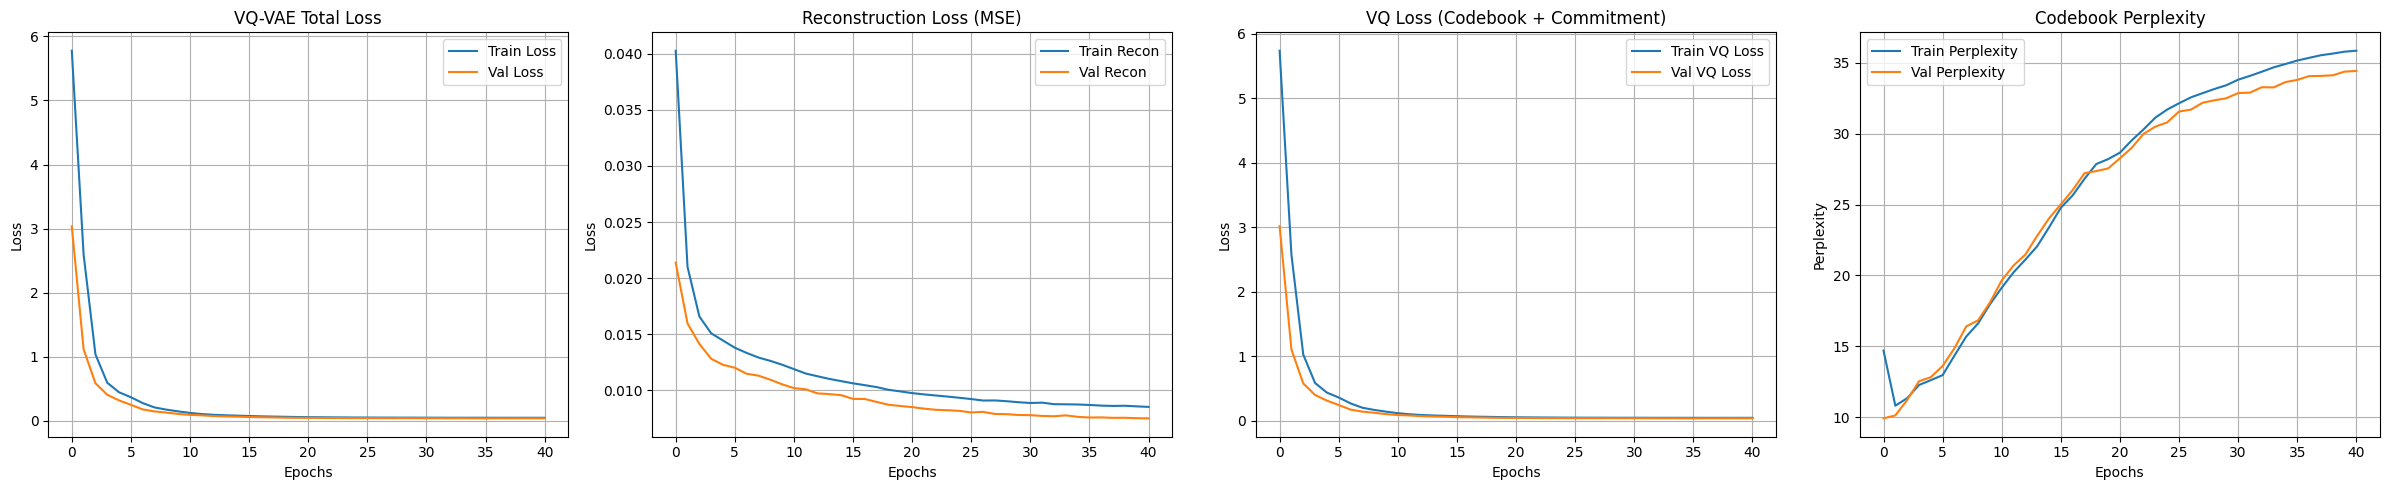

In [33]:
# Plot training and validation loss curves
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Total loss
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_title("VQ-VAE Total Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Reconstruction loss
axes[1].plot(train_recon_losses, label="Train Recon")
axes[1].plot(val_recon_losses, label="Val Recon")
axes[1].set_title("Reconstruction Loss (MSE)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

# VQ loss
axes[2].plot(train_vq_losses, label="Train VQ Loss")
axes[2].plot(val_vq_losses, label="Val VQ Loss")
axes[2].set_title("VQ Loss (Codebook + Commitment)")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(True)

# Perplexity: measures codebook utilization
# Higher perplexity = more codebook entries are being used (desired)
axes[3].plot(train_perplexities, label="Train Perplexity")
axes[3].plot(val_perplexities, label="Val Perplexity")
axes[3].set_title("Codebook Perplexity")
axes[3].set_xlabel("Epochs")
axes[3].set_ylabel("Perplexity")
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25523/2869088700.py:106: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  - 2.0 * z_e_flat @ self.embedding.weight.t()        # (N, K)
/tmp/ipykernel_25523/2869088700.py:114: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable d

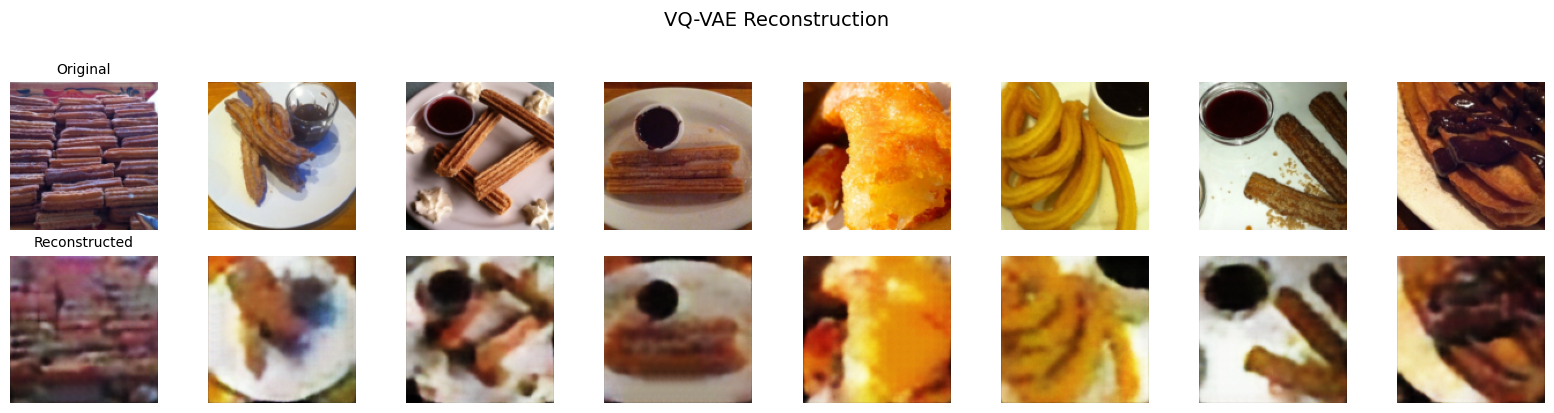

In [34]:
def visualize_reconstructions(model, loader, num_images=8):
    """
    Visualize original images vs. their VQ-VAE reconstructions.
    """
    model.eval()
    images, _ = next(iter(loader))
    images = images[:num_images].to(device)

    with torch.no_grad():
        reconstructed, _, _, _, _, _ = model(images)

    images = images.cpu()
    reconstructed = reconstructed.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        # Original
        axes[0, i].imshow(images[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=10)

        # Reconstructed
        axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=10)

    plt.suptitle('VQ-VAE Reconstruction', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


visualize_reconstructions(model, test_loader)

# 8. Test Evaluation

In [35]:
# Evaluate on the test set
test_loss, test_recon, test_vq, test_perp = validate_epoch(model, test_loader)
print(
    f"Test Loss: {test_loss:.6f} "
    f"(Recon: {test_recon:.6f}, VQ: {test_vq:.4f}, Perplexity: {test_perp:.1f})"
)

Validation:   0%|          | 0/49 [00:16<?, ?it/s]

/tmp/ipykernel_25523/2869088700.py:106: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  - 2.0 * z_e_flat @ self.embedding.weight.t()        # (N, K)
/tmp/ipykernel_25523/2869088700.py:114: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable d

Test Loss: 0.040603 (Recon: 0.007439, VQ: 0.0332, Perplexity: 32.3)


# 9. Codebook Analysis

A key diagnostic for VQ-VAE is to inspect how well the codebook is utilized.
- **Perplexity** close to `NUM_EMBEDDINGS` means all codebook entries are used equally (ideal).
- **Codebook collapse**: only a few entries are used repeatedly. This leads to poor reconstruction quality.

We visualize the codebook usage distribution across the test set.

Analyzing Codebook:   0%|          | 0/49 [00:00<?, ?it/s]

/tmp/ipykernel_25523/2869088700.py:106: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  - 2.0 * z_e_flat @ self.embedding.weight.t()        # (N, K)
/tmp/ipykernel_25523/2869088700.py:114: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable d

Codebook entries used: 64 / 512 (12.5%)


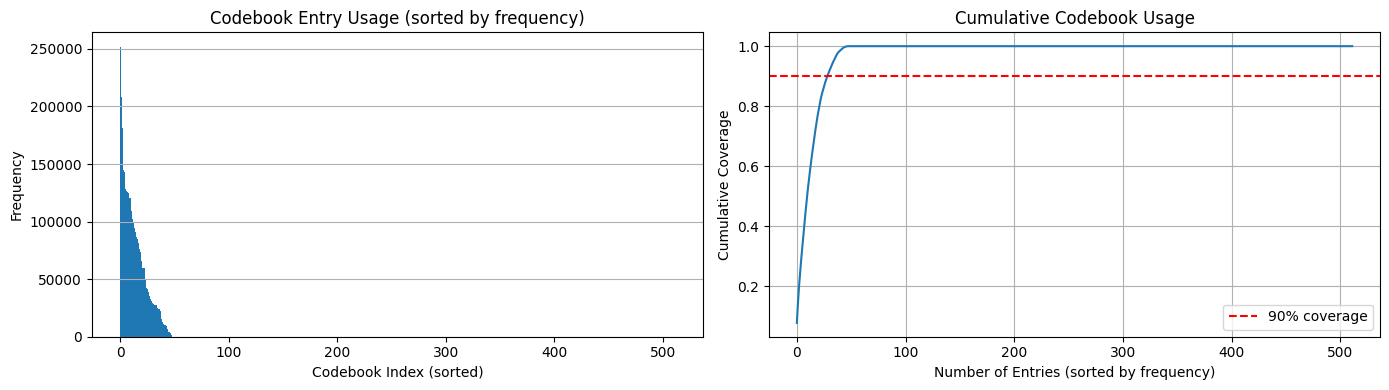

In [36]:
def analyze_codebook_usage(model, loader, num_embeddings):
    """
    Compute and visualize the codebook usage distribution over the given loader.

    Args:
        model:          Trained VQ-VAE model.
        loader:         DataLoader to evaluate codebook usage on.
        num_embeddings: Total number of codebook entries.
    """
    model.eval()
    usage_counts = torch.zeros(num_embeddings)

    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Analyzing Codebook", leave=False):
            images = images.to(device)
            # encoding_indices shape: (B, H*W)
            _, _, _, _, encoding_indices, _ = model(images)
            indices_cpu = encoding_indices.cpu().view(-1)
            for idx in indices_cpu:
                usage_counts[idx.item()] += 1

    # Percentage of entries ever used
    used_entries = (usage_counts > 0).sum().item()
    usage_percent = 100.0 * used_entries / num_embeddings
    print(f"Codebook entries used: {used_entries} / {num_embeddings} ({usage_percent:.1f}%)")

    # Sort by frequency for visualization
    sorted_counts, _ = usage_counts.sort(descending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Usage frequency bar chart
    axes[0].bar(range(num_embeddings), sorted_counts.numpy(), width=1.0)
    axes[0].set_title("Codebook Entry Usage (sorted by frequency)")
    axes[0].set_xlabel("Codebook Index (sorted)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, axis='y')

    # Cumulative usage curve
    cumulative = sorted_counts.cumsum(0)
    cumulative = cumulative / cumulative[-1]  # Normalize to [0, 1]
    axes[1].plot(range(num_embeddings), cumulative.numpy())
    axes[1].axhline(0.9, color='r', linestyle='--', label='90% coverage')
    axes[1].set_title("Cumulative Codebook Usage")
    axes[1].set_xlabel("Number of Entries (sorted by frequency)")
    axes[1].set_ylabel("Cumulative Coverage")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


analyze_codebook_usage(model, test_loader, NUM_EMBEDDINGS)

# 10. Latent Space Sampling (Generative)

Unlike a standard VAE, sampling from a VQ-VAE requires sampling from the
**discrete** prior over codebook indices. A common approach is to sample
random codebook indices uniformly and decode them.

For high-quality generation, a prior model (e.g. PixelCNN) would be trained
over the discrete indices. Here we demonstrate uniform random sampling as a
simple baseline to visualize the codebook's expressiveness.

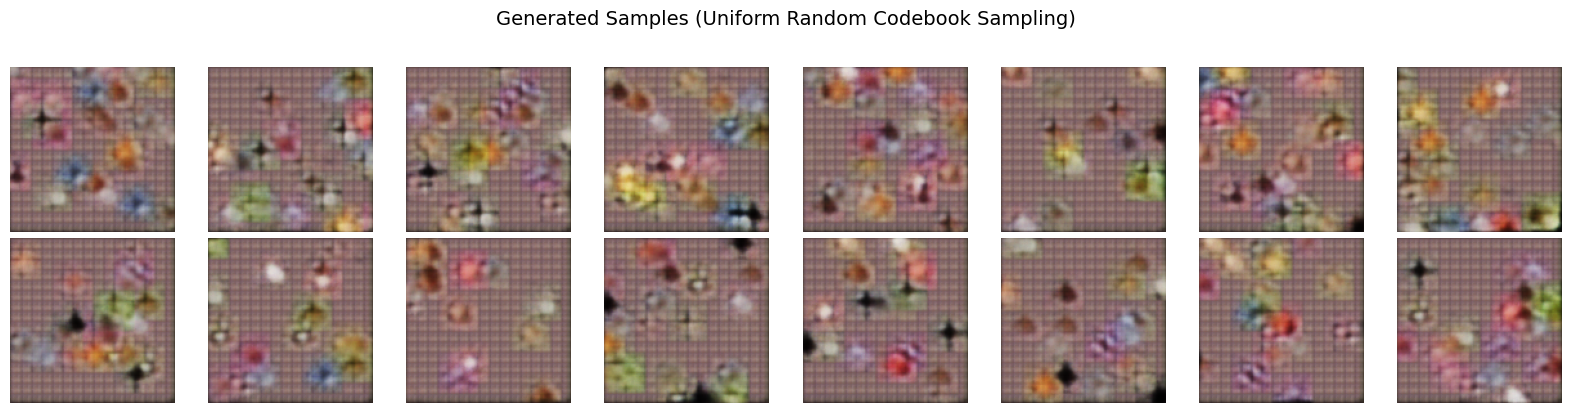

In [37]:
def generate_from_codebook(model, num_samples=16):
    """
    Generate new images by sampling random codebook indices and decoding them.

    This is a uniform random prior over the discrete latent space.
    For better generation quality, a learned prior (e.g. PixelCNN) is needed.

    Args:
        model:       Trained VQ-VAE model.
        num_samples: Number of images to generate.
    """
    model.eval()
    with torch.no_grad():
        # Spatial size of the quantized feature map
        h = model.final_h
        w = model.final_w
        n_positions = h * w

        # Sample random codebook indices: (num_samples, H*W)
        random_indices = torch.randint(
            0, model.vq_layer.num_embeddings, (num_samples, n_positions)
        ).to(device)

        # Retrieve the corresponding codebook vectors: (num_samples * H*W, D)
        embeddings = model.vq_layer.embedding(random_indices.view(-1))

        # Reshape to (num_samples, D, H, W) for the decoder
        z_q = embeddings.view(num_samples, h, w, model.vq_layer.embedding_dim)
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        generated = model.decode(z_q).cpu()

    # Plot generated images
    cols = min(8, num_samples)
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    if rows == 1:
        axes = axes[np.newaxis, :]

    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            if idx < num_samples:
                axes[i, j].imshow(generated[idx].permute(1, 2, 0).clamp(0, 1))
            axes[i, j].axis('off')

    plt.suptitle("Generated Samples (Uniform Random Codebook Sampling)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


generate_from_codebook(model, num_samples=16)

# 11. Latent Space Interpolation

In the discrete VQ-VAE latent space, we interpolate between two images
using their continuous encoder outputs z_e (before quantization).
The intermediate z values are then quantized and decoded.

This shows how smoothly the VQ-VAE transitions between two images in its
learned representation space.

/tmp/ipykernel_25523/2869088700.py:106: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  - 2.0 * z_e_flat @ self.embedding.weight.t()        # (N, K)
/tmp/ipykernel_25523/2869088700.py:114: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable d

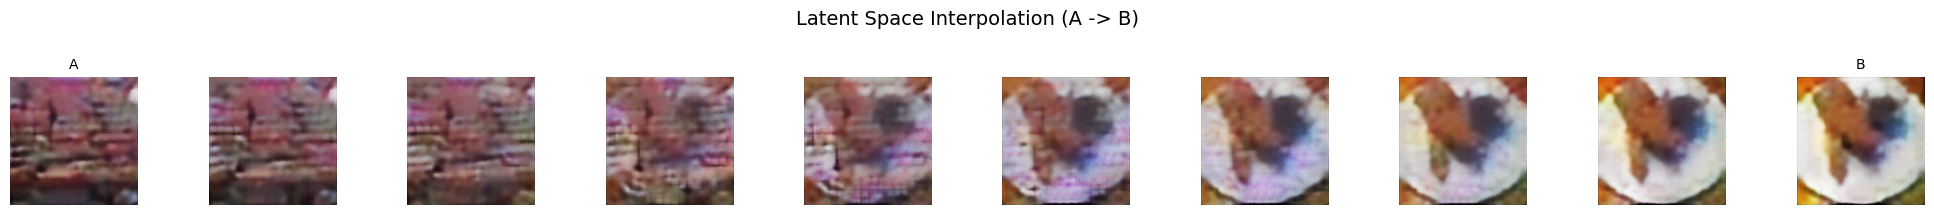

In [38]:
def interpolate_latent(model, loader, num_steps=10):
    """
    Interpolate between two images in the continuous encoder latent space
    (z_e before quantization), then quantize and decode the intermediate points.

    Args:
        model:     Trained VQ-VAE model.
        loader:    DataLoader to sample two images from.
        num_steps: Number of interpolation steps (including endpoints).
    """
    model.eval()
    images, _ = next(iter(loader))
    img_a = images[0:1].to(device)
    img_b = images[1:2].to(device)

    with torch.no_grad():
        # Get continuous encoder outputs (before VQ)
        z_e_a = model.encode(img_a)
        z_e_b = model.encode(img_b)

        # Linear interpolation in the continuous latent space
        interpolations = []
        for alpha in np.linspace(0, 1, num_steps):
            z_interp = (1 - alpha) * z_e_a + alpha * z_e_b
            # Quantize the interpolated vector and decode
            z_q, _, _, _, _, _ = model.vq_layer(z_interp)
            decoded = model.decode(z_q)
            interpolations.append(decoded.cpu())

    fig, axes = plt.subplots(1, num_steps, figsize=(num_steps * 2, 2))
    for i, img in enumerate(interpolations):
        axes[i].imshow(img[0].permute(1, 2, 0).clamp(0, 1))
        axes[i].axis('off')
        if i == 0:
            axes[i].set_title('A', fontsize=10)
        elif i == num_steps - 1:
            axes[i].set_title('B', fontsize=10)

    plt.suptitle('Latent Space Interpolation (A -> B)', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()


interpolate_latent(model, test_loader)